# Stage 03: Classical Features & Numbers-First LLM Interpretation

## Overview
This notebook demonstrates classical Otsu thresholding, morphological cleanup, connected-component analysis, and regionprops feature extraction, followed by numbers-first LLM reasoning.


In [5]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import json

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.lower() == "notebooks" else CURRENT_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import preprocess_image, load_mask
from src.classical_features import segment_classical, extract_features, summarize_features
from src.vlm import query_llm_numbers_first


## 1. Classical Segmentation Pipeline


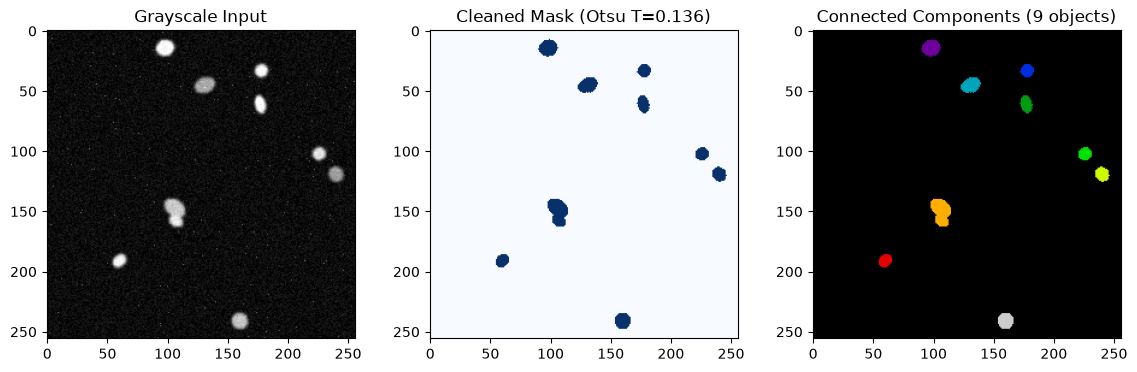

In [6]:
data_dir = PROJECT_ROOT / "data" / "nuclei_dataset"
if not data_dir.exists():
    data_dir = PROJECT_ROOT / "nuclei_dataset"

img_p = data_dir / "train" / "images" / "train_000.png"
img_np = preprocess_image(img_p)
cleaned_mask, labeled_mask, thresh = segment_classical(img_np)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(img_np, cmap="gray")
axes[0].set_title("Grayscale Input")
axes[1].imshow(cleaned_mask, cmap="Blues")
axes[1].set_title(f"Cleaned Mask (Otsu T={thresh:.3f})")
axes[2].imshow(labeled_mask, cmap="nipy_spectral")
axes[2].set_title(f"Connected Components ({labeled_mask.max()} objects)")
plt.show()


## 2. Quantitative Morphometrics & Numeric Summarization


In [7]:
features_df = extract_features(labeled_mask, intensity_image=img_np, image_id="train_000")
print("Per-object feature table preview:")
display(features_df.head())

summary_dict = summarize_features(features_df, image_id="train_000")
print()
print("Generated Numeric Summary string:")
print(summary_dict["numeric_text"])


Per-object feature table preview:


,image_id,label,area,eccentricity,solidity,perimeter,equivalent_diameter,mean_intensity,max_intensity,min_intensity
0,train_000,1,171.0,0.476409,0.939560,47.698485,14.755472,0.298995,0.346789,0.136467
1,train_000,2,97.0,0.212625,0.979798,33.798990,11.113246,0.286278,0.346789,0.137032
2,train_000,3,164.0,0.702809,0.953488,47.698485,14.450304,0.213101,0.338648,0.136749
3,train_000,4,115.0,0.774863,0.934959,40.041631,12.100518,0.287161,0.346789,0.137032
4,train_000,5,98.0,0.331551,0.980000,33.556349,11.170384,0.261829,0.339764,0.140403



Generated Numeric Summary string:
Image train_000: Quantitative segmentation identified 9 distinct cellular nuclei occupying a total area of 1282 pixels (1.96% field coverage). Individual nucleus area averages 142.4 ± 60.6 pixels (range 97–285). Mean eccentricity is 0.504 and mean solidity is 0.956, indicating predominantly regular elliptical shapes. Mean foreground pixel intensity is 0.258. Density is classified as sparse.


## 3. Numbers-First LLM Reasoning
Passing quantitative measurements to text-only LLM without images.


In [8]:
llm_res = query_llm_numbers_first(summary_dict["numeric_text"], model="llama3.2")
print("LLM Interpretation:")
print(llm_res.get("raw_response", ""))


LLM Interpretation:
The microscopy image contains 9 distinct cellular nuclei, occupying a total area of 1282 pixels, which accounts for 1.96% of the field coverage. The individual nucleus area averages 142.4 pixels, with a range of 97-285 pixels. The nuclei exhibit regular elliptical shapes, as indicated by a mean eccentricity of 0.504 and a mean solidity of 0.956. The mean foreground pixel intensity is 0.258, suggesting a relatively low intensity. The density of the nuclei is classified as sparse.

{
    "n_objects": 9,
    "density_class": "sparse",
    "shape_regularity": "regular",
    "quality_flag": "pass",
    "rationale": "The image contains 9 distinct nuclei with regular elliptical shapes, occupying a relatively small area, and exhibiting low foreground pixel intensity, consistent with a sparse density."
